In [171]:
# Imports
import numpy as np # For storing data and performing computations
SEED = 57131605 # For deterministic testing

In [172]:
# Parse Data
import email
from email import policy
from pathlib import Path

# Parser
def parse_path(path: Path) -> list[str]:
    out = []
    for file in path.glob('*.txt'):
        with open(file=file, mode='r', encoding='latin-1') as f:
            try:
                message = email.message_from_file(f, policy=policy.default)
                subject = message['subject'] or '' # Get subject message (set to an empty string if not provided)
                body = ""
                if message.is_multipart():
                    for part in message.walk():
                        if part.get_content_type() == 'text/plain':
                            body += part.get_content()
                else:
                    body = message.get_content()
                out.append(subject + " " + body)
            except Exception as e:
                print(f'Failed on {file}: {e}')
                return []
    return out

# Parse folders
spam_emails = parse_path(Path('enron1/spam'))
ham_emails = parse_path(Path('enron1/ham'))

In [173]:
# Clean data
import re

# Transform every email string into a list of words
def tokenize(text: str) -> list[str]:
    text = text.lower() # Standard formatting
    text = re.sub(r'\d+', ' ', text) # Remove digits
    text = re.sub(r'\W+', ' ', text) # Remove other erroneous characters
    return text.split()

# Tokenize email strings
spam_tokens = [t for t in map(tokenize, spam_emails)]
ham_tokens = [t for t in map(tokenize, ham_emails)]

In [174]:
# TF-IDF model

# Finding highest frequency counts
word2count = dict()
for lst in spam_tokens + ham_tokens:
    for token in lst:
        if token in word2count:
            word2count[token] += 1
        else:
            word2count[token] = 1

# HYPERPARAMETER: number of words kept -- N_WORDS
N_WORDS = 2000
import heapq
freq_words = set(heapq.nlargest(N_WORDS, word2count, key=word2count.get))

# Truncate Dictionary:
word2count = {w: word2count[w] for w in word2count if w in freq_words}

# Word to Index
WtoI = {w:i for i, w in enumerate(freq_words)}

# Construct word vectors
TF = np.zeros(shape=(5172, 2000), dtype=float)
ys = np.concatenate((np.zeros(shape=(1500,), dtype=float) - 1, np.zeros(shape=(3672,), dtype=float) + 1))

# Construct Bag of Words vectors
for i, tokens in enumerate(spam_tokens + ham_tokens):
    for token in tokens:
        if token in freq_words:
            TF[i, WtoI[token]] += 1 / len(tokens)

IDF = np.log(len(TF) / (np.sum(a=TF, axis=0, keepdims=False) + 1))
xs = TF * IDF
xs = xs / (np.linalg.norm(xs) + 1e-12)

np.random.seed(SEED)
permut = np.random.permutation(len(xs))

def norm(X, mu, sigma):
    return (X - mu) / (sigma + 1e-12)

xs = xs[permut]
ys = ys[permut]

# Create datasplits
x_train = xs[:4138]
y_train = ys[:4138]
x_test = xs[4138:4655]
y_test = ys[4138:4655]
x_dev = xs[4655:]
y_dev = ys[4655:]

# Normalize
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train = norm(x_train, mean, std)
x_test = norm(x_test, mean, std)
x_dev = norm(x_dev, mean, std)


In [175]:
# Kernel -- The type of kernel is a hyper parameter
# However will just use Cosine RBF Kernel

def rbf_kernel_matrix(X, sigma):
    norms = np.linalg.norm(X, axis=1) + 1e-10 # Shape (n)
    cos = (X @ X.T) / (norms[:, None] * norms[None, :]) # Shape (n, n)
    cos = np.clip(cos, -1.0, 1.0)
    return np.exp(-sigma * (1.0 - cos))

In [176]:
# Kernel SVM

# Perform Optimization on Lagrange Multiplier Vector: L
def grad_descent(H, X, Y, C, iters=int(1e3)):
    L = np.zeros(shape=(len(X)), dtype=float)
    yy = Y @ Y
    epsilon = 0.1
    for _ in range(1, iters + 1):
        epsilon /= np.sqrt(_)
        grad = H @ L - 1.0
        L -= epsilon * grad # Step
        L -= ((Y @ L) / yy) * Y # Project onto Hyperplane to maintain constraint
        L = np.clip(L, 0.0, C, out=L) # Enforce Non-Negativity

        pg = (grad).copy()
        pg[(L <= 1e-12) & (grad >= 0)] = 0.0   # box @ lower bound
        pg[(L >= C - 1e-12) & (grad <= 0)] = 0.0  # box @ upper bound
        if np.linalg.norm(pg) < 1e-3:
            break
    return L

def train(X, Y, C, K):
    H = np.outer(Y, Y) * K
    L = grad_descent(H, X, Y, C)


    return L

In [177]:
# Retrieve bias from Lagrange multiplier vector
def get_b(Y, L, K, C=1.0, tol=1e-5):
    mask = (L > tol) & (L < C - tol)
    supp_idcs = np.where(mask)[0]
    B = np.mean([
        Y[i] - np.sum(L * Y * K[:, i])
        for i in supp_idcs
    ])
    return B

# Define prediction function
def rbf_predict(L, B, X_test, sigma, X_train, Y_train):
    N_test = np.linalg.norm(X_test, axis=1, keepdims=True) + 1e-10 # Shape (m, 1)
    N_train = np.linalg.norm(X_train, axis=1, keepdims=True) + 1e-10 # Shape (1, n)
    cos = (X_test @ X_train.T) / (N_test @ N_train.T) # Shape (m, n)
    K = np.exp(-sigma * (1 - cos))
    preds = K @ (L * Y_train) + B # Shape (m)
    return np.sign(preds)


def get_accuracy(L, X, Y, B, sigma, x_train, y_train):
    y_preds = rbf_predict(L, B, X, sigma, x_train, y_train)
    return np.mean(y_preds == Y)

In [178]:
pot_sigma = np.linspace(1.5, 2.2, 3)
pot_C = np.linspace(2, 3, 3)
acc = np.zeros(shape=(len(pot_sigma), len(pot_C)), dtype=float)

for i, sigma in enumerate(pot_sigma):
    K = rbf_kernel_matrix(x_train, sigma)
    for j, C in enumerate(pot_C):
        L = train(x_train, y_train, C, K)
        B = get_b(y_train, L, K, C)
        acc[i, j] = get_accuracy(L, x_dev, y_dev, B, sigma, x_train, y_train)
i, j = np.unravel_index(np.argmax(acc), shape=(len(pot_sigma), len(pot_C)))
print(pot_sigma[i], pot_C[j])


1.5 2.0


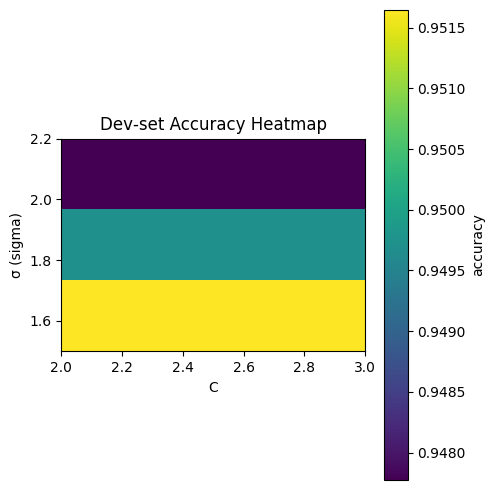

In [179]:
from matplotlib import pyplot as plt
plt.figure(figsize=(5,5))
plt.imshow(acc,
           origin='lower',
           extent=(pot_C.min(), pot_C.max(),
                   pot_sigma.min(), pot_sigma.max()),
           interpolation='nearest')
plt.colorbar(label='accuracy')
plt.xlabel('C')
plt.ylabel('σ (sigma)')
plt.title('Dev‐set Accuracy Heatmap')
plt.tight_layout()
plt.show()

In [180]:
# Post Model and Hyperparam training
sigma = 1.5
C = 2.0
K = rbf_kernel_matrix(x_train, sigma)
L = train(x_train, y_train, C, K)
B = get_b(y_train, L, K, C)

# Make predictions -- For diagnostic tests
y_preds = rbf_predict(L, B, x_test, sigma, x_train, y_train)

# Assess Predictions
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds, target_names=["Spam", "Ham"]))

              precision    recall  f1-score   support

        Spam       0.97      0.95      0.96       153
         Ham       0.98      0.99      0.98       364

    accuracy                           0.98       517
   macro avg       0.97      0.97      0.97       517
weighted avg       0.98      0.98      0.98       517



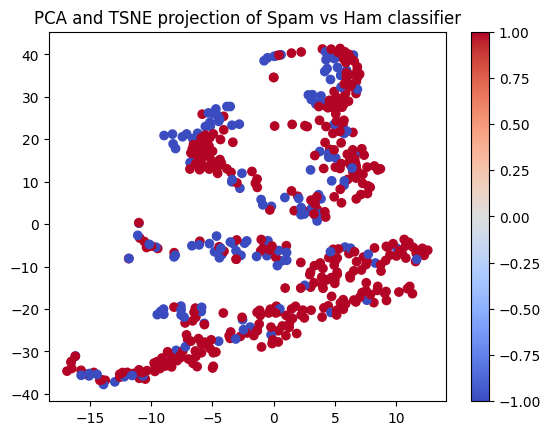

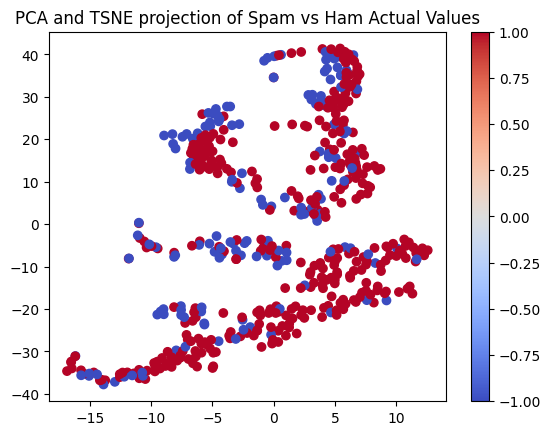

In [181]:
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2)
x_vis = pca.fit_transform(x_test)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_vis = tsne.fit_transform(x_vis)

plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_preds, cmap='coolwarm')
plt.colorbar()
plt.title('PCA and TSNE projection of Spam vs Ham classifier')
plt.show()

plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_test, cmap='coolwarm')
plt.colorbar()
plt.title('PCA and TSNE projection of Spam vs Ham Actual Values')
plt.show()